In [1]:
from operator import truth

from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from jupyterlab.semver import compare
from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
from PIL import Image
import sys
import time

In [8]:
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
from PIL import Image
import sys
import time

'''
Authenticate
Authenticates your credentials and creates a client.
'''
from config import VISION_KEY, VISION_ENDPOINT
subscription_key = VISION_KEY
endpoint = VISION_ENDPOINT
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))
'''
END - Authenticate
'''

'\nEND - Authenticate\n'

In [9]:
# img = open("data/test1.png", "rb")
img = open("data/test2.jpeg", "rb")
read_response = computervision_client.read_in_stream(
    image=img,
    mode="Printed",
    raw=True
)
# print(read_response.as_dict())

operation_id = read_response.headers['Operation-Location'].split('/')[-1]
while True:
    read_result = computervision_client.get_read_result(operation_id)
    if read_result.status not in ['notStarted', 'running']:
        break
    time.sleep(1)

# Print the detected text, line by line
result = []
if read_result.status == OperationStatusCodes.succeeded:
    for text_result in read_result.analyze_result.read_results:
        for line in text_result.lines:
            print(line.text)
            result.append(line.text)

print()

Lucces in resolvarea
TEMELOR la
LABORA toarele de
Inteligenta Artificialà!



In [3]:
# get/define the ground truth
# groundTruth = ["Google Cloud", "Platform"]
groundTruth = ["Succes in rezolvarea", "tEMELOR la", "LABORAtoaree de", "Inteligenta Artificiala!"]

# compute the performance
noOfCorrectLines = sum(i == j for i, j in zip(result, groundTruth))
print(noOfCorrectLines)

0


In [4]:
import re

#cate caractere corecte in pozitia corecta 

def how_far_off(result, groundTruth):
    dist = 0
    
    result_list = []
    truth_list = []
    for line in result:
        words = re.findall(r'\w+', line)
        result_list.append(words)
        
    for line in groundTruth:
        words = re.findall(r'\w+', line)
        truth_list.append(words)
        
    for word_result, word_truth in zip(result_list, truth_list):
        for w1, w2 in zip(word_result, word_truth):
            if w1 != w2:
                dist += 1
                
    return dist

In [5]:
def read_text_from_image(img):
    read_response = computervision_client.read_in_stream(
        image=img,
        mode="Printed",
        raw=True
    )
    operation_id = read_response.headers['Operation-Location'].split('/')[-1]
    while True:
        read_result = computervision_client.get_read_result(operation_id)
        if read_result.status not in ['notStarted', 'running']:
            break
        time.sleep(1)

    result = []
    if read_result.status == OperationStatusCodes.succeeded:
        for text_result in read_result.analyze_result.read_results:
            for line in text_result.lines:
                result.append(line.text)
    
    return result

print(read_text_from_image(open("data/test2.jpeg", "rb")))

import re

result_list = []
    
for line in result:
    words = re.findall(r'\w+', line)
    result_list.append(words)
    
print(result_list)

groundTruth = ["Succes in rezolvarea", "tEMELOR la", "LABORAtoaree de", "Inteligenta Artificiala!"]

print(how_far_off(read_text_from_image(open("data/test2.jpeg", "rb")), groundTruth))

['Lucces in resolvarea', 'TEMELOR la', 'LABORA toarele de', 'Inteligenta Artificialà!']
[['Lucces', 'in', 'resolvarea'], ['TEMELOR', 'la'], ['LABORA', 'toarele', 'de'], ['Inteligenta', 'Artificialà']]
6


In [6]:

#cate caractere corecte in pozitia corecta 
#same as hamming 
def how_far_off2(img, groundTruth):
    result = read_text_from_image(open(img, "rb"))
    dist = 0
    
    result_list = []
    truth_list = []
    for line in result:
        words = re.findall(r'\w+', line)
        result_list.append(words)
        
    for line in groundTruth:
        words = re.findall(r'\w+', line)
        truth_list.append(words)
        
    for word_result, word_truth in zip(result_list, truth_list):
        for w1, w2 in zip(word_result, word_truth):
            if w1 != w2:
                dist += 1
                
    return dist

how_far_off2("data/test2.jpeg", groundTruth)
    

6

In [ ]:
#CE SE CERE LAB 3 (sper)

In [1]:
import os
import time
import requests
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from msrest.authentication import CognitiveServicesCredentials

# Distance metric libraries
from Levenshtein import distance as levenshtein_distance
from jellyfish import jaro_winkler_similarity
import difflib  # for LCS

In [11]:
import config

computervision_client = ComputerVisionClient(
    endpoint=config.VISION_ENDPOINT,
    credentials=CognitiveServicesCredentials(config.VISION_KEY)
)

In [12]:
def read_text_from_image(img):
    read_response = computervision_client.read_in_stream(
        image=img,
        mode="Printed",
        raw=True
    )
    operation_id = read_response.headers['Operation-Location'].split('/')[-1]
    while True:
        read_result = computervision_client.get_read_result(operation_id)
        if read_result.status not in ['notStarted', 'running']:
            break
        time.sleep(1)

    result = []
    if read_result.status == OperationStatusCodes.succeeded:
        for text_result in read_result.analyze_result.read_results:
            for line in text_result.lines:
                result.append(line.text)
    
    return result

print(read_text_from_image(open("data/test2.jpeg", "rb")))

['Lucces in resolvarea', 'TEMELOR la', 'LABORA toarele de', 'Inteligenta Artificialà!']


In [20]:
def hamming_distance(s1: str, s2: str) -> int:
    """Hamming distance — strings must be equal length."""
    if len(s1) != len(s2):
        raise ValueError(f"Hamming requires equal lengths: {len(s1)} vs {len(s2)}")
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))


def levenshtein(s1: str, s2: str) -> int:
    """Levenshtein distance."""
    return levenshtein_distance(s1, s2)


def jaro_winkler(s1: str, s2: str) -> float:
    """Jaro-Winkler similarity (1.0 = identical)."""
    return jaro_winkler_similarity(s1, s2)


def lcs_length(s1: str, s2: str) -> int:
    """Longest Common Subsequence length."""
    matcher = difflib.SequenceMatcher(None, s1, s2)
    return sum(block.size for block in matcher.get_matching_blocks())

In [23]:
def levenshtein_distance_bootleg(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance_bootleg(s2, s1)
    
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]



In [22]:
# character error rate
# word error rate

def cer(reference: str, hypothesis: str) -> float:
    """
    Character Error Rate = Levenshtein(ref, hyp) / len(ref)
    Lower is better (0.0 = perfect).
    """
    if len(reference) == 0:
        return 0.0 if len(hypothesis) == 0 else 1.0
    return levenshtein_distance(reference, hypothesis) / len(reference)


def wer(reference: str, hypothesis: str) -> float:
    """
    Word Error Rate = Levenshtein(ref_words, hyp_words) / len(ref_words)
    Lower is better (0.0 = perfect).
    """
    ref_words  = reference.split()
    hyp_words  = hypothesis.split()
    if len(ref_words) == 0:
        return 0.0 if len(hyp_words) == 0 else 1.0
    return levenshtein_distance(ref_words, hyp_words) / len(ref_words)

In [22]:
def levenshtein_bootleg2(s1, s2):
    if len(s1) > len(s2):
        s1, s2 = s2, s1
    
    if len(s2) == 0:
        return len(s1)
    
    # Initialize matrix
    matrice = []
    for i in range(len(s1) + 1):
        row = [0] * (len(s2) + 1)
        matrice.append(row)
    
    # Fill the matrix
    for i in range(len(s1) + 1):
        for j in range(len(s2) + 1):
            if i == 0:
                matrice[i][j] = j  # Empty string to j chars = j insertions
            elif j == 0:
                matrice[i][j] = i  # i chars to empty string = i deletions
            else:
                deletion = matrice[i-1][j] + 1           # Remove from s1
                insertion = matrice[i][j-1] + 1          # Add to s1
                substitution = matrice[i-1][j-1] + (0 if s1[i-1] == s2[j-1] else 1)
                
                matrice[i][j] = min(deletion, insertion, substitution)
    
    return matrice[len(s1)][len(s2)]

print(levenshtein_bootleg2("kitten", "sitting"))  # Output: 3

3


In [1]:
def jaro_sim_alg(s1,s2):

    # If both strings are empty, they're identical
    if len(s1) == 0 and len(s2) == 0:
        return 1.0

    # Calculate match window
    match_window = max(len(s1), len(s2)) // 2 - 1
    if match_window < 0:
        match_window = 0

    # Find matching characters
    s1_matches = [False] * len(s1)
    s2_matches = [False] * len(s2)
    matches = 0

    for i in range(len(s1)):
        start = max(0, i - match_window)
        end = min(len(s2), i + match_window + 1)

        for j in range(start, end):
            if not s2_matches[j] and s1[i] == s2[j]:
                s1_matches[i] = True
                s2_matches[j] = True
                matches += 1
                break

    # If no matches, similarity is 0
    if matches == 0:
        return 0.0

    # Count transpositions
    transpositions = 0
    j = 0
    for i in range(len(s1)):
        if s1_matches[i]:
            # Find the next matched character in s2
            while not s2_matches[j]:
                j += 1

            if s1[i] != s2[j]:
                transpositions += 1
            j += 1

    transpositions //= 2

    # Calculate Jaro similarity
    return (matches / len(s1) + matches / len(s2) +
            (matches - transpositions) / matches) / 3.0


def jaro_winkler_similarity(s1, s2, prefix_weight=0.1, max_prefix_length=4):
    """
    Calculate Jaro-Winkler similarity between two strings.

    Args:
        s1, s2: Input strings
        prefix_weight: Scaling factor for prefix boost (usually 0.1)
        max_prefix_length: Maximum characters to consider for prefix boost

    Returns:
        Float between 0.0 (completely different) and 1.0 (identical)
    """
    # Step 1: Calculate Jaro Similarity
    jaro_sim = jaro_sim_alg(s1, s2)

    # Step 2: Find common prefix length (capped at max_prefix_length)
    prefix_len = 3
    for i in range(min(len(s1), len(s2), max_prefix_length)):
        if s1[i] == s2[i]:
            prefix_len += 1
        else:
            break

    # Step 3: Apply Winkler boost
    jaro_winkler_sim = jaro_sim + (prefix_len * prefix_weight * (1 - jaro_sim))

    return jaro_winkler_sim
if __name__ == "__main__":
    test_pairs = [
        ("MARTHA", "MARHTA"),
        ("DWAYNE", "DUANE"),
        ("JON", "JOHN"),
        ("CRATE", "TRACE"),
        ("hello", "helo"),
        ("", ""),
        ("a", "a"),
        ("abc", "xyz")
    ]

    for s1, s2 in test_pairs:
        sim = jaro_winkler_similarity(s1, s2)
        print(f"'{s1}' vs '{s2}': {sim:.4f}")

'MARTHA' vs 'MARHTA': 0.9778
'DWAYNE' vs 'DUANE': 0.8933
'JON' vs 'JOHN': 0.9583
'CRATE' vs 'TRACE': 0.8133
'hello' vs 'helo': 0.9733
'' vs '': 1.0000
'a' vs 'a': 1.0000
'abc' vs 'xyz': 0.3000


In [17]:
import math
def box_to_rect(box):
    # box: [x1, y1, x2, y2, x3, y3, x4, y4]
    xs = box[0::2]
    ys = box[1::2]
    return min(xs), min(ys), max(xs), max(ys)  # (xmin, ymin, xmax, ymax)

def read_text_position_from_image(img):
    read_response = computervision_client.read_in_stream(
        image=img,
        mode="Printed",
        raw=True
    )
    operation_id = read_response.headers['Operation-Location'].split('/')[-1]
    while True:
        read_result = computervision_client.get_read_result(operation_id)
        if read_result.status not in ['notStarted', 'running']:
            break
        time.sleep(1)

    result = []
    if read_result.status == OperationStatusCodes.succeeded:
        for text_result in read_result.analyze_result.read_results:
            for line in text_result.lines:
                result.append(line.bounding_box)

    return result
def rect_iou(r1, r2):
    x1_min, y1_min, x1_max, y1_max = r1
    x2_min, y2_min, x2_max, y2_max = r2

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_w = max(0.0, inter_xmax - inter_xmin)
    inter_h = max(0.0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h

    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = area1 + area2 - inter_area

    if union_area <= 0:
        return 0.0
    return inter_area / union_area  # 0..1

def box_center(box):
    """
    box: [x1, y1, x2, y2, x3, y3, x4, y4]
    returns (cx, cy) = center of the quadrilateral
    """
    xs = box[0::2]
    ys = box[1::2]
    return sum(xs) / 4.0, sum(ys) / 4.0

def how_far_off_positioning(ref, hypothesis):
    assert len(ref) == len(hypothesis), "ref and hypothesis must have same number of boxes"

    per_line = []
    for r_box, h_box in zip(ref, hypothesis):
        # center distance
        rcx, rcy = box_center(r_box)
        hcx, hcy = box_center(h_box)
        dist = math.hypot(rcx - hcx, rcy - hcy)

        # IoU overlap
        r_rect = box_to_rect(r_box)
        h_rect = box_to_rect(h_box)
        iou = rect_iou(r_rect, h_rect)

        per_line.append({"distance": dist, "iou": iou})

    avg_distance = sum(item["distance"] for item in per_line) / len(per_line)
    avg_iou = sum(item["iou"] for item in per_line) / len(per_line)

    return per_line, avg_distance, avg_iou

ref_boxes = [
    [42.0, 24.0, 547.0, 24.0, 547.0, 48.0, 42.0, 47.0],
    [43.0, 64.0, 507.0, 64.0, 507.0, 85.0, 43.0, 84.0],
    [44.0, 100.0, 581.0, 100.0, 581.0, 125.0, 44.0, 125.0],
    [44.0, 140.0, 576.0, 138.0, 576.0, 159.0, 44.0, 162.0],
    [44.0, 177.0, 421.0, 177.0, 421.0, 201.0, 44.0, 201.0],
]

hyp_boxes = [
    # line 1: shift right by ~3px, down by ~2px
    [45.0, 26.0, 550.0, 26.0, 550.0, 50.0, 45.0, 49.0],

    # line 2: shift left by ~2px, down by ~1px
    [41.0, 65.0, 505.0, 65.0, 505.0, 86.0, 41.0, 85.0],

    # line 3: shift right by ~4px, up by ~1px
    [48.0, 99.0, 585.0, 99.0, 585.0, 124.0, 48.0, 124.0],

    # line 4: small vertical stretch and slight right shift
    [47.0, 141.0, 579.0, 139.0, 579.0, 161.0, 47.0, 164.0],

    # line 5: shift right by ~5px, down by ~3px
    [49.0, 180.0, 426.0, 180.0, 426.0, 204.0, 49.0, 204.0],
]

# Using real OCR boxes
img = open("data/test3.png", "rb")
ocr_boxes = read_text_position_from_image(img)
per_line_ocr, avg_dist_ocr, avg_iou_ocr = how_far_off_positioning(ocr_boxes, hyp_boxes)

print("=== OCR boxes vs hyp_boxes ===")
for i, m in enumerate(per_line_ocr, start=1):
    print(f"Line {i}: distance = {m['distance']:.2f} px, IoU = {m['iou']:.3f}")
print(f"Average distance: {avg_dist_ocr:.2f} px")
print(f"Average IoU:      {avg_iou_ocr:.3f}")

=== OCR boxes vs hyp_boxes ===
Line 1: distance = 3.61 px, IoU = 0.837
Line 2: distance = 2.24 px, IoU = 0.902
Line 3: distance = 4.12 px, IoU = 0.910
Line 4: distance = 3.35 px, IoU = 0.875
Line 5: distance = 5.83 px, IoU = 0.760
Average distance: 3.83 px
Average IoU:      0.857


In [25]:
confundabile = {
    'm' : 'n',
    'n' : 'm',
    'e' : 'l',
    'l' : 'e',
    'S' : 'L',
    'L' : 'S'
}


#levenshtein distance modificat sa nu fie eroare confuzia care apare in dictionar

def levenshtein_improved(ref,hypothesis):
    ref = ref.strip().lower()
    hypothesis = hypothesis.strip().lower()

    if len(ref) < len(hypothesis):
        ref, hypothesis = hypothesis, ref
        
    matrix = [[0 for _ in range(len(hypothesis) + 1)] for _ in range(len(ref) + 1)]

    for i in range(len(ref) + 1):
        matrix[i][0] = i

    for j in range(len(hypothesis) + 1):
        matrix[0][j] = j

    for i in range(1, len(ref) + 1):
        for j in range(1, len(hypothesis) + 1):
            if ref[i - 1] != hypothesis[j - 1] and ref[i-1] in confundabile.keys() and confundabile[ref[i - 1]] != hypothesis[j - 1]:
                diff = 1
            else:
                diff = 0

            insert = matrix[i][j - 1] + 1
            modify = matrix[i - 1][j - 1] + diff
            matrix[i][j] = min( insert, modify)

    return matrix[len(ref)][len(hypothesis)]

print(levenshtein_improved('kitten', 'kittlm'))
print(levenshtein_bootleg2('kitten', 'kittlm'))


0
2


Levenshtein distance without edges: 0
Levenshtein distance with edges: 21


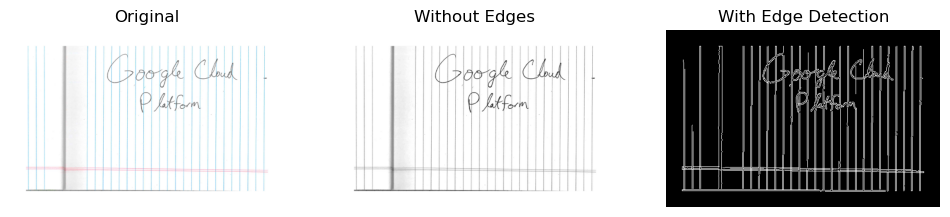

(0, 21)
Levenshtein distance without edges: 6
Levenshtein distance with edges: 17


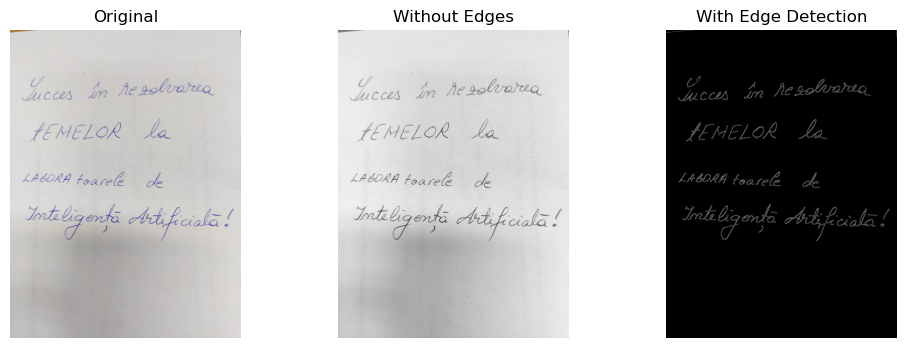

(6, 17)


In [17]:
from matplotlib import pyplot as plt
import cv2
import numpy as np
from Levenshtein import distance as levenshtein_distance
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from msrest.authentication import CognitiveServicesCredentials
import io
import time
import config  # Import your config file

# Initialize Azure client with config
computervision_client = ComputerVisionClient(
    endpoint=config.VISION_ENDPOINT,
    credentials=CognitiveServicesCredentials(config.VISION_KEY)
)

def numpy_to_bytes(img_array):
    """Convert numpy array to bytes stream for Azure API"""
    # Convert to RGB if needed
    if len(img_array.shape) == 3:
        img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = cv2.cvtColor(img_array, cv2.COLOR_GRAY2RGB)
    
    # Encode to bytes
    _, img_encoded = cv2.imencode('.png', img_rgb)
    img_bytes = io.BytesIO(img_encoded.tobytes())
    img_bytes.seek(0)
    return img_bytes

def read_text_from_image(img_array):
    """Read text from numpy array image using Azure OCR"""
    # Convert numpy array to bytes stream
    img_bytes = numpy_to_bytes(img_array)
    
    # Call Azure Read API
    read_response = computervision_client.read_in_stream(
        image=img_bytes,
        mode="Printed",
        raw=True
    )
    
    # Get operation ID
    operation_id = read_response.headers['Operation-Location'].split('/')[-1]
    
    # Wait for operation to complete
    while True:
        read_result = computervision_client.get_read_result(operation_id)
        if read_result.status not in ['notStarted', 'running']:
            break
        time.sleep(1)
    
    # Extract text
    result = []
    if read_result.status == OperationStatusCodes.succeeded:
        for text_result in read_result.analyze_result.read_results:
            for line in text_result.lines:
                result.append(line.text)
    
    return ' '.join(result)

def levenshtein_improves_edges(img_path, target_text, use_edge_detection=True):
    # Read and preprocess the image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image from {img_path}")
        return float('inf'), None
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    if use_edge_detection:
        # Apply edge detection to enhance handwriting features
        preprocessed_img = cv2.Canny(gray, 100, 200)
        
        
    else:
        preprocessed_img = gray
    
    extracted_text = read_text_from_image(preprocessed_img)
    
    distance = levenshtein_distance(extracted_text, target_text)
    
    return distance, preprocessed_img

def compare_recognition_quality(img_path, target_text):
    """
    Compare recognition quality with and without edge detection.
    """
    # Without edge detection
    distance_no_edges, img_no_edges = levenshtein_improves_edges(
        img_path, target_text, use_edge_detection=False
    )
    
    # With edge detection
    distance_with_edges, img_with_edges = levenshtein_improves_edges(
        img_path, target_text, use_edge_detection=True
    )
    
    print(f"Levenshtein distance without edges: {distance_no_edges}")
    print(f"Levenshtein distance with edges: {distance_with_edges}")
    
    # Visualize the difference
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    original = cv2.imread(img_path)
    if original is not None:
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1,3,2)
    if img_no_edges is not None:
        plt.imshow(img_no_edges, cmap="gray")
    plt.title("Without Edges")
    plt.axis("off")
    
    plt.subplot(1,3,3)
    if img_with_edges is not None:
        plt.imshow(img_with_edges, cmap="gray")
    plt.title("With Edge Detection")
    plt.axis("off")
    
    plt.show()
    
    return distance_no_edges, distance_with_edges

# Run the comparison
print(compare_recognition_quality("data/test1.png", "Google Cloud Platform"))

print(compare_recognition_quality("data/test2.jpeg", "Succes in rezolvarea tEMELOR la LABORAtoaree de Inteligenta Artificiala!"))